二分类的交叉熵\
应用函数-log(x),x->1,-log(x)接近0惩罚小,x->0,-log(x)->+infity,惩罚大\
核心思想：事情已经发生y=1:pred就应该越大越好，那么惩罚量应该小-log(pred)\
         事情没有发生y=0:pred就应该越小越好，否则惩罚加大-log(1-pred)、
         
\begin{flalign*}
J(w) &= -\frac{1}{m}\sum_{i=1}^{m}[y^{(i)}\log(y^{(i)}_{pred})+(1-y^{(i)})\log(1-y^{(i)}_{pred})]&\\
y_{pred}&=\sigma(z)=\frac{1}{1+e^{-z}}&\\
z &=w^Tx&\\
\frac{\partial J}{\partial w_j}&=\frac{\partial J}{\partial y_{pred}}\frac{\partial y_{pred}}{\partial z}\frac{\partial z}{\partial w_j}&\\
\frac{\partial J}{\partial y_{pred}}&=-\frac{y}{y_{pred}}+\frac{1-y}{1-y_{pred}}&\\
\frac{\partial y_{pred}}{\partial z}&=\sigma^{'}(z)=\frac{e^{-z}}{(1+e^{-z})^2}&\\
&=\sigma(z)(1-\sigma(z))&\\
&=y_{pred}(1-y_{pred})&\\
\frac{\partial J}{\partial z}&=\frac{\partial J}{\partial y_{pred}}\frac{\partial y_{pred}}{\partial z}&\\
&=y_{pred}-y&\\
\frac{\partial z}{\partial w_j}&=x_j&\\
\frac{\partial J}{\partial w_j}&=(y_{pred}-y)x_j&\\
\frac{\partial J}{\partial w}&=\frac{1}{m}X^T(y_{pred}-y)
\end{flalign*}


\begin{flalign*}
\end{flalign*}

In [1]:
import numpy as np
import pandas as pd
from template_lr import LinearRegressionGD
df_raw=pd.read_csv("exam_pass.csv")
df=df_raw.copy()
#标准化
cols_to_scale=[
    'study_hours',
    'mock_score'
]
cols_y=['passed']
#下面两行用于还原最后w系数
means=df[cols_to_scale].mean(axis=0)
stds=df[cols_to_scale].std(axis=0,ddof=0)
#标准化代码
df[cols_to_scale]=(df[cols_to_scale]-means)/stds
#特征值记录
feature_names = df.drop(cols_y, axis=1).columns.tolist()
#变量定义
Y=df[cols_y].values.flatten()
X_raw=df.drop(cols_y,axis=1).values
m=X_raw.shape[0]
X=np.hstack((np.ones((m,1)),X_raw))
n=X.shape[1]
#定义信号函数
def sigmoid(z):
    z = np.asarray(z)
    out = np.empty_like(z, dtype=float)

    pos = z >= 0
    neg = ~pos

    out[pos] = 1 / (1 + np.exp(-z[pos]))

    exp_z = np.exp(z[neg])
    out[neg] = exp_z / (1 + exp_z)

    return out
#梯度下降
alpha=0.1
n_iters=1000
cost_history=[]
grad_history=[]
w=np.zeros((n,))
for i in range(n_iters):
    z=X@w
    pred=sigmoid(z)
    err=pred-Y
    grad=(X.T@err)/m
    w=w-alpha*grad
    eps = 1e-15
    cost = -np.mean(Y * np.log(pred + eps) + (1 - Y) * np.log(1 - pred + eps))
    cost_history.append(cost)
    grad_history.append(np.linalg.norm(grad))
#w还原
cols_to_scale_idx = [feature_names.index(col) for col in cols_to_scale]

intercept_scaled = w[0]
coef_scaled = w[1:].copy()
coef_original = coef_scaled.copy()

means_arr = means[cols_to_scale].to_numpy()
stds_arr = stds[cols_to_scale].to_numpy()

coef_original[cols_to_scale_idx] = coef_scaled[cols_to_scale_idx] / stds_arr

intercept_original = intercept_scaled - np.sum(
    coef_scaled[cols_to_scale_idx] * means_arr / stds_arr
)

w_original = np.hstack([
    intercept_original,
    coef_original
])

In [2]:
pred_label = (sigmoid(X @ w) >= 0.5).astype(int)
accuracy = np.mean(pred_label == Y)
print("accuracy:", accuracy)   # 0.835

accuracy: 0.835


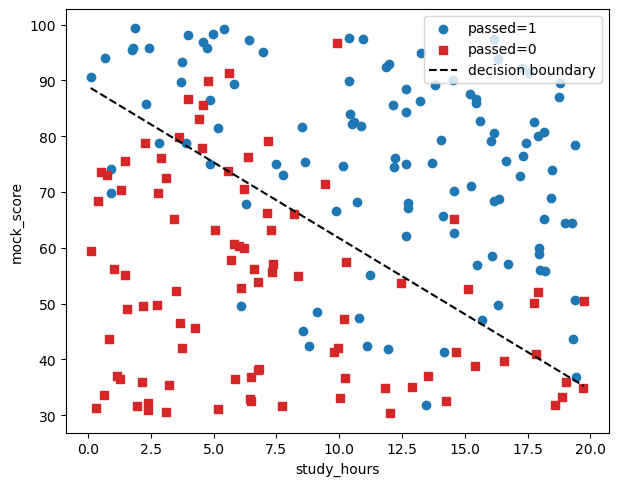

In [3]:
import matplotlib.pyplot as plt

study = df_raw['study_hours'].values   # 用未标准化的原始数据画，单位才有意义
score = df_raw['mock_score'].values
y_raw = df_raw['passed'].values

plt.figure(figsize=(7, 5.5))
plt.scatter(study[y_raw==1], score[y_raw==1], c='C0', label='passed=1')
plt.scatter(study[y_raw==0], score[y_raw==0], c='C3', marker='s', label='passed=0')

# 用还原后的原始尺度系数 w_original = [b_o, coef0, coef1]
b_o, c0, c1 = w_original
xs = np.array([study.min(), study.max()])
ys = -(b_o + c0 * xs) / c1            # 由 b_o + c0*x1 + c1*x2 = 0 解出 x2
plt.plot(xs, ys, 'k--', label='decision boundary')

plt.xlabel('study_hours'); plt.ylabel('mock_score'); plt.legend()
plt.show()